# OpenDecision — Phase 4A.2 StateQuery Model Comparison

**Purpose:** compare a matched candidate-conditioned control (B0), a source-balanced direct StateQuery model (B1), and the factorized StateQuery model (B2) against the completed Phase 4A.1 run—without rebuilding the corpus, rerunning the 4B backbone, or opening the final split.

**Workbench version:** `4a.2.0`  
**Immutable input run:** `20260921T013558Z`  
**Frozen backbone:** `Qwen/Qwen3.5-4B-Base@1001bb4d826a52d1f399e183466143f4da7b741b`  
**Reference bundle:** `4d9ffdee0aea5c71c666d0feae372cffe79a05934aedee2245012e3a53c23332`

This is a new follow-on notebook. It never writes into the completed Phase 4A.1 run. It consumes that run only after checking its corpus lock, table hashes, feature manifest, selected checkpoint hash, and non-final report hash.

It inherits the split, source-separation, state-level averaging, probability, and lock discipline documented in the pinned [SemIf Phase 1 method](https://github.com/TheoLeeCJ/SemIf/blob/ca3ba65f142967030ecb453346e94d6f476a69df/docs/METHOD.md). The base run's recorded method provenance is part of the immutable input contract; no SemIf fixtures are used as training data.

The final split is not configurable here. A separate confirmatory notebook is required after a comparison winner and numerical promotion gates have been frozen.


## Recommended run order

Run one variant at a time, each in a fresh Colab GPU runtime:

| Order | `VARIANT` | What it answers |
|---:|---|---|
| 1 | `b0_matched_control` | Does new supervision help when Qwen still sees each candidate? |
| 2 | `b1_balanced` | Does direct StateQuery recover after source balancing and semantic-none weighting? |
| 3 | `b2_factorized` | Do compact question evidence slots improve transfer and semantic-none behavior? |
| 4 | `b2r_refined` | Optional: add a once-per-state refiner only after B2 is competitive. |

In the configuration cell, set `RUN_VARIANT=True`. Leave `RESUME=True`. If Colab disconnects, reconnect, run the notebook from the top with the same `VARIANT` and `RUN_LABEL`, and it will resume after the latest completed epoch. If a variant already completed, its saved report is loaded instead of retraining.

Use a new `RUN_LABEL` if you change a scientific hyperparameter. The notebook refuses to overwrite an existing label whose contract differs.


## 1. Runtime and dependency contract

Select a Colab GPU runtime. The install is constrained so pip cannot silently replace Colab's Torch build.


In [1]:
import sys, subprocess, importlib.metadata as im, json, os, platform
from pathlib import Path

def installed(name):
    try:
        return im.version(name)
    except im.PackageNotFoundError:
        return None

torch_version = installed("torch")
if torch_version is None:
    raise RuntimeError("Select a Colab GPU runtime with PyTorch installed.")

constraint = Path("/content/opendecision_phase4a2_torch_constraint.txt")
constraint.write_text(f"torch=={torch_version}\n")
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "-c", str(constraint),
    "transformers==5.17.0",
    "accelerate==1.14.0",
    "safetensors==0.8.0",
    "numpy>=2,<3",
    "scipy>=1.16,<2",
    "pandas>=2,<3",
    "scikit-learn>=1.6,<2",
    "pyarrow>=18,<30",
    "matplotlib>=3.9,<4",
])
if installed("torch") != torch_version:
    raise RuntimeError("Torch changed unexpectedly during dependency installation.")

ENVIRONMENT = {
    "python": sys.version,
    "platform": platform.platform(),
    "packages": {name: installed(name) for name in (
        "torch", "transformers", "accelerate", "safetensors", "numpy",
        "scipy", "pandas", "scikit-learn", "pyarrow", "matplotlib",
    )},
}
print(json.dumps(ENVIRONMENT, indent=2))
if not torch_version.startswith("2.11."):
    print("WARNING: the original cache was produced in the Torch 2.11 family.")


{
  "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "packages": {
    "torch": "2.11.0+cu128",
    "transformers": "5.17.0",
    "accelerate": "1.14.0",
    "safetensors": "0.8.0",
    "numpy": "2.1.3",
    "scipy": "1.16.3",
    "pandas": "2.2.3",
    "scikit-learn": "1.6.1",
    "pyarrow": "23.0.1",
    "matplotlib": "3.10.0"
  }
}


## 2. Mount Google Drive

The original run stays read-only. New results go to a separate Phase 4A.2 results tree under `Colab Notebooks`.


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


## 3. Choose exactly one comparison variant

The default is the recommended first run. Change only `VARIANT`, `RUN_LABEL`, and `RUN_VARIANT` for normal use.

- `RUN_VARIANT=False` performs preflight checks and shows any existing comparison results.
- `RUN_VARIANT=True` trains/resumes the selected variant and performs its non-final evaluation.
- `RECOMPUTE_NONFINAL=False` loads an existing non-final report rather than rewriting it.


In [3]:
import hashlib, random, re, shutil, zipfile, gc
from collections import defaultdict
from dataclasses import dataclass, asdict
from datetime import datetime, timezone

WORKBENCH_VERSION = "4a.2.0"
BASE_RUN_ID = "20260921T013558Z"
SEED = 17

VARIANT = "b0_matched_control"     # b0_matched_control | b1_balanced | b2_factorized | b2r_refined
RUN_LABEL = VARIANT                 # change this when changing a scientific hyperparameter
RUN_VARIANT = True                 # explicit opt-in: train/resume + non-final evaluation
RESUME = True
RECOMPUTE_NONFINAL = False

VARIANT_RECIPES = {
    "b0_matched_control": {"architecture": "B0", "state_refiner_layers": 0},
    "b1_balanced": {"architecture": "B1", "state_refiner_layers": 0},
    "b2_factorized": {"architecture": "B2", "state_refiner_layers": 0},
    "b2r_refined": {"architecture": "B2R", "state_refiner_layers": 1},
}
if VARIANT not in VARIANT_RECIPES:
    raise ValueError(f"Unknown variant: {VARIANT}")
if not re.fullmatch(r"[a-z0-9][a-z0-9._-]{0,79}", RUN_LABEL):
    raise ValueError("RUN_LABEL must be a short path-safe identifier.")

CFG = {
    "schema": "opendecision-phase4a2-config/v1",
    "workbench_version": WORKBENCH_VERSION,
    "base_run_id": BASE_RUN_ID,
    "variant": VARIANT,
    "run_label": RUN_LABEL,
    **VARIANT_RECIPES[VARIANT],
    "seed": SEED,
    "query_dim": 768,
    "query_heads": 12,
    "query_layers": 2,
    "question_latents": 8,
    "max_question_tokens": 96,
    "max_candidate_tokens": 64,
    "epochs": 12,
    "patience": 4,
    "gradient_accumulation_states": 4,
    "learning_rate": 2e-4,
    "weight_decay": 0.01,
    "evidence_loss_weight": 0.15,
    "reason_loss_weight": 0.10,
    "source_balance_strategy": "undersample_to_smallest_source_each_epoch",
    "semantic_none_weight_sources": ["qasper"],
    "semantic_none_weight_cap": 5.0,
    "minimum_development_none_recall": {"contractnli": 0.35, "qasper": 0.30},
    "policy_wrong_cost": 5.0,
    "policy_review_cost": 0.10,
}

COLAB_ROOT = Path("/content/drive/MyDrive/Colab Notebooks")
BASE_RUN = COLAB_ROOT / "OpenDecision_Phase4A_StateQuery_results" / BASE_RUN_ID
COMPARISON_ROOT = (
    COLAB_ROOT / "OpenDecision_Phase4A2_StateQuery_Model_Comparison_results" / BASE_RUN_ID
)
VARIANT_DIR = COMPARISON_ROOT / RUN_LABEL
LOCAL_ROOT = Path("/content/opendecision_phase4a2") / BASE_RUN_ID / RUN_LABEL
LOCAL_CACHE = Path("/content/opendecision_phase4a2_cache") / BASE_RUN_ID
for path in (COMPARISON_ROOT, VARIANT_DIR, LOCAL_ROOT, LOCAL_CACHE):
    path.mkdir(parents=True, exist_ok=True)

print(json.dumps(CFG, indent=2))
print("Immutable input:", BASE_RUN)
print("Variant output:", VARIANT_DIR)


{
  "schema": "opendecision-phase4a2-config/v1",
  "workbench_version": "4a.2.0",
  "base_run_id": "20260921T013558Z",
  "variant": "b0_matched_control",
  "run_label": "b0_matched_control",
  "architecture": "B0",
  "state_refiner_layers": 0,
  "seed": 17,
  "query_dim": 768,
  "query_heads": 12,
  "query_layers": 2,
  "question_latents": 8,
  "max_question_tokens": 96,
  "max_candidate_tokens": 64,
  "epochs": 12,
  "patience": 4,
  "gradient_accumulation_states": 4,
  "learning_rate": 0.0002,
  "weight_decay": 0.01,
  "evidence_loss_weight": 0.15,
  "reason_loss_weight": 0.1,
  "source_balance_strategy": "undersample_to_smallest_source_each_epoch",
  "semantic_none_weight_sources": [
    "qasper"
  ],
  "semantic_none_weight_cap": 5.0,
  "minimum_development_none_recall": {
    "contractnli": 0.35,
    "qasper": 0.3
  },
  "policy_wrong_cost": 5.0,
  "policy_review_cost": 0.1
}
Immutable input: /content/drive/MyDrive/Colab Notebooks/OpenDecision_Phase4A_StateQuery_results/20260921T0

## 4. Verify the immutable Phase 4A.1 inputs

This preflight re-hashes every normalized corpus table and verifies the completed B1 checkpoint/report against its model-selection lock. Feature shards are copied to ephemeral local storage and checked against the Stage A feature manifest the first time they are used. Thus every non-final feature actually consumed by a variant is verified once, then reused locally across epochs.

Final state features may exist in the Stage A cache, but this notebook's store refuses every `final` access before resolving a path.


In [4]:
import numpy as np
import pandas as pd

def canonical_bytes(obj):
    return json.dumps(obj, sort_keys=True, separators=(",", ":"), ensure_ascii=False).encode()

def sha256_obj(obj):
    return hashlib.sha256(canonical_bytes(obj)).hexdigest()

def sha256_file(path, chunk=4 * 1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as handle:
        while block := handle.read(chunk):
            h.update(block)
    return h.hexdigest()

def read_json(path):
    return json.loads(Path(path).read_text())

def atomic_json(obj, destination):
    destination = Path(destination)
    tmp = destination.with_name(destination.name + ".partial")
    tmp.write_text(json.dumps(obj, indent=2, ensure_ascii=False))
    os.replace(tmp, destination)

required_base = [
    "DECLARED_CONTRACT.json", "TRAINING_REPORT.json", "NONFINAL_EVALUATION.json",
    "MODEL_SELECTION_LOCK.json", "query_model_best.safetensors",
    "reference_nonfinal_predictions.parquet",
]
missing = [name for name in required_base if not (BASE_RUN / name).is_file()]
if missing:
    raise FileNotFoundError(f"Incomplete base run {BASE_RUN_ID}: {missing}")
if (BASE_RUN / "FINAL_EVALUATION.json").exists():
    raise RuntimeError("The base run's final split has been opened; this comparison notebook expects it closed.")

BASE_DECLARED = read_json(BASE_RUN / "DECLARED_CONTRACT.json")
claimed_declared_hash = BASE_DECLARED.get("sha256")
declared_payload = dict(BASE_DECLARED)
declared_payload.pop("sha256", None)
if sha256_obj(declared_payload) != claimed_declared_hash:
    raise RuntimeError("The base declared contract changed.")
MODEL_CONTRACT = BASE_DECLARED["model"]

CORPUS_ROOT = BASE_RUN / "opendecision-mq-v1"
CORPUS_MANIFEST = read_json(CORPUS_ROOT / "manifest.json")
CORPUS_LOCK = read_json(CORPUS_ROOT / "corpus_lock.json")
if CORPUS_MANIFEST["run_id"] != BASE_RUN_ID:
    raise RuntimeError("Corpus run ID mismatch.")
if sha256_obj(CORPUS_MANIFEST) != CORPUS_LOCK["manifest_sha256"]:
    raise RuntimeError("Corpus manifest no longer matches its lock.")
if CORPUS_MANIFEST.get("final_labels_or_predictions_opened") is not False:
    raise RuntimeError("Corpus manifest does not attest that final stayed closed.")

frames = {}
for name, expected_hash in CORPUS_LOCK["tables"].items():
    path = CORPUS_ROOT / f"{name}.parquet"
    got_hash = sha256_file(path)
    if got_hash != expected_hash:
        raise RuntimeError(f"Changed corpus table {name}: {got_hash}")
    frames[name] = pd.read_parquet(path)
    if len(frames[name]) != CORPUS_MANIFEST["counts"][name]:
        raise RuntimeError(f"Row count changed for {name}.")

FEATURE_ROOT = BASE_RUN / "state_features"
FEATURE_MANIFEST_PATH = FEATURE_ROOT / "manifest.json"
FEATURE_MANIFEST = read_json(FEATURE_MANIFEST_PATH)
if FEATURE_MANIFEST["run_id"] != BASE_RUN_ID:
    raise RuntimeError("Feature-cache run ID mismatch.")
if FEATURE_MANIFEST["corpus_manifest_sha256"] != CORPUS_LOCK["manifest_sha256"]:
    raise RuntimeError("Feature cache belongs to another corpus.")
if FEATURE_MANIFEST.get("reference_predictions_exclude_final") is not True:
    raise RuntimeError("Stage A did not attest that reference predictions exclude final.")
manifest_state_ids = [r["state_id"] for r in FEATURE_MANIFEST["state_files"]]
if len(manifest_state_ids) != len(set(manifest_state_ids)):
    raise RuntimeError("Duplicate state IDs in feature manifest.")
if set(manifest_state_ids) != set(frames["states"]["state_id"]):
    raise RuntimeError("Feature manifest does not cover the locked state table exactly.")
final_state_ids = set(frames["states"].loc[frames["states"]["split"] == "final", "state_id"])
final_question_ids = set(
    frames["questions"].loc[frames["questions"]["state_id"].isin(final_state_ids), "question_id"]
)
control_question_ids = {
    r["question_id"] for r in FEATURE_MANIFEST.get("candidate_conditioned_control_files", [])
}
if control_question_ids & final_question_ids:
    raise RuntimeError("Matched-control cache unexpectedly includes final questions.")

BASE_TRAINING = read_json(BASE_RUN / "TRAINING_REPORT.json")
BASE_NONFINAL = read_json(BASE_RUN / "NONFINAL_EVALUATION.json")
BASE_LOCK = read_json(BASE_RUN / "MODEL_SELECTION_LOCK.json")
if any(x.get("final_opened") is not False for x in (BASE_TRAINING, BASE_NONFINAL, BASE_LOCK)):
    raise RuntimeError("A base report does not attest that final remained closed.")
if sha256_file(BASE_RUN / "query_model_best.safetensors") != BASE_LOCK["checkpoint_sha256"]:
    raise RuntimeError("Base selected checkpoint changed.")
if sha256_file(BASE_RUN / "NONFINAL_EVALUATION.json") != BASE_LOCK["nonfinal_report_sha256"]:
    raise RuntimeError("Base non-final report changed.")

BASE_ARTIFACT_HASHES = {
    "declared_contract": sha256_file(BASE_RUN / "DECLARED_CONTRACT.json"),
    "corpus_manifest": sha256_file(CORPUS_ROOT / "manifest.json"),
    "corpus_lock": sha256_file(CORPUS_ROOT / "corpus_lock.json"),
    "feature_manifest": sha256_file(FEATURE_MANIFEST_PATH),
    "base_training_report": sha256_file(BASE_RUN / "TRAINING_REPORT.json"),
    "base_nonfinal_report": sha256_file(BASE_RUN / "NONFINAL_EVALUATION.json"),
    "base_model_lock": sha256_file(BASE_RUN / "MODEL_SELECTION_LOCK.json"),
    "base_selected_checkpoint": sha256_file(BASE_RUN / "query_model_best.safetensors"),
    "reference_nonfinal_predictions": sha256_file(BASE_RUN / "reference_nonfinal_predictions.parquet"),
}
EXPERIMENT_PAYLOAD = {
    "schema": "opendecision-phase4a2-experiment/v1",
    "config": CFG,
    "base_artifacts": BASE_ARTIFACT_HASHES,
    "model_contract": MODEL_CONTRACT,
    "corpus_lock": CORPUS_LOCK,
    "final_split_available": False,
}
EXPERIMENT_SHA256 = sha256_obj(EXPERIMENT_PAYLOAD)
EXPERIMENT_CONTRACT = {**EXPERIMENT_PAYLOAD, "experiment_sha256": EXPERIMENT_SHA256}
contract_path = VARIANT_DIR / "EXPERIMENT_CONTRACT.json"
if contract_path.exists():
    existing = read_json(contract_path)
    if existing.get("experiment_sha256") != EXPERIMENT_SHA256:
        raise RuntimeError(
            f"RUN_LABEL={RUN_LABEL!r} already has a different contract. Choose a new RUN_LABEL."
        )
else:
    atomic_json(EXPERIMENT_CONTRACT, contract_path)

if VARIANT == "b2r_refined" and RUN_VARIANT:
    prerequisite = COMPARISON_ROOT / "b2_factorized" / "NONFINAL_EVALUATION.json"
    if not prerequisite.is_file():
        raise RuntimeError("Run and review b2_factorized before the optional B2R refinement.")

display(frames["states"].groupby(["source", "split"]).size().rename("states").reset_index())
print("Verified corpus tables:", {name: len(df) for name, df in frames.items()})
print("State feature records:", len(FEATURE_MANIFEST["state_files"]))
print("Control-question records:", len(control_question_ids))
print("Experiment contract:", EXPERIMENT_SHA256)


,source,split,states
0,contractnli,calibration_fit,34
1,contractnli,calibration_gate,71
2,contractnli,development,70
3,contractnli,final,52
4,contractnli,policy_development,39
5,contractnli,train,341
6,qasper,calibration_fit,119
7,qasper,calibration_gate,199
8,qasper,development,242
9,qasper,final,217


Verified corpus tables: {'states': 2192, 'questions': 15368, 'options': 25687, 'evidence': 21894, 'criteria': 18}
State feature records: 2192
Control-question records: 13725
Experiment contract: 509f1f4c07cfe05f2a67b8ad62f1c3d045714ab00610299a95d79213595f1c7e


## 5. Verify and extract the exact tokenizer bundle

The 4B model is not loaded in this notebook. Only the selected bundle's tokenizer is used for B1/B2 query and candidate text, and the already-cached frozen input embedding is used for token lookup.


In [5]:
EXPECTED_BUNDLE = (
    COLAB_ROOT / "OpenDecision_Phase2IJ_results"
    / "2ij_model_selection_screen_v2"
    / "model_bundle_2ij_model_selection_screen_v2.zip"
)
LOCAL_BUNDLE = LOCAL_CACHE / "reference_bundle"

def safe_extract(zpath, destination):
    destination = destination.resolve()
    with zipfile.ZipFile(zpath) as zf:
        for member in zf.infolist():
            target = (destination / member.filename).resolve()
            if not target.is_relative_to(destination):
                raise RuntimeError(f"Unsafe ZIP member: {member.filename}")
        zf.extractall(destination)

if not EXPECTED_BUNDLE.is_file():
    raise FileNotFoundError(EXPECTED_BUNDLE)
if sha256_file(EXPECTED_BUNDLE) != MODEL_CONTRACT["bundle_sha256"]:
    raise RuntimeError("Selected reference bundle changed.")
LOCAL_BUNDLE.mkdir(parents=True, exist_ok=True)
if not (LOCAL_BUNDLE / "BUNDLE_MANIFEST.json").is_file():
    safe_extract(EXPECTED_BUNDLE, LOCAL_BUNDLE)
bundle_manifest = read_json(LOCAL_BUNDLE / "BUNDLE_MANIFEST.json")
bundle_profile = read_json(LOCAL_BUNDLE / "profile.json")
if bundle_manifest["profile_id"] != MODEL_CONTRACT["profile_id"]:
    raise RuntimeError("Bundle profile mismatch.")
if bundle_manifest["base"]["id"] != MODEL_CONTRACT["model_id"]:
    raise RuntimeError("Bundle model mismatch.")
if bundle_manifest["base"]["revision"] != MODEL_CONTRACT["revision"]:
    raise RuntimeError("Bundle revision mismatch.")
for rel, expected in bundle_manifest["files"].items():
    path = LOCAL_BUNDLE / rel
    if not path.is_file() or sha256_file(path) != expected:
        raise RuntimeError(f"Missing or changed bundle member: {rel}")
print("Verified tokenizer bundle:", bundle_profile["profile_id"])


Verified tokenizer bundle: a047d6802c3f06f085b8


## 6. B0/B1/B2 architectures and the permanent BF16 fix

The architecture definitions are inherited from Phase 4A.1. Probability assembly is now forced to FP32 outside autocast, checked at a BF16-appropriate tolerance, and explicitly renormalized. This permanently fixes the observed `0.998046875` assertion without weakening the probability contract.


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

REASON_LABELS = ("applicable", "omitted_option", "out_of_scope", "insufficient_evidence", "unobservable_state")

class CrossBlock(nn.Module):
    def __init__(self, d_model, nhead, dropout=0.1, ff_mult=4):
        super().__init__()
        self.n1 = nn.LayerNorm(d_model)
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.n2 = nn.LayerNorm(d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.n3 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_mult * d_model), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(ff_mult * d_model, d_model), nn.Dropout(dropout),
        )

    def forward(self, x, memory, x_padding=None, memory_padding=None, return_attention=False):
        y = self.n1(x)
        y, _ = self.self_attn(y, y, y, key_padding_mask=x_padding, need_weights=False)
        x = x + y
        y = self.n2(x)
        y, weights = self.cross_attn(
            y, memory, memory,
            key_padding_mask=memory_padding,
            need_weights=return_attention,
            average_attn_weights=False,
        )
        x = x + y
        x = x + self.ff(self.n3(x))
        return x, weights

class QueryStack(nn.Module):
    def __init__(self, layers, d_model, nhead, dropout=0.1):
        super().__init__()
        self.layers = nn.ModuleList([CrossBlock(d_model, nhead, dropout) for _ in range(layers)])
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x, memory, x_padding=None, memory_padding=None):
        attention = None
        for i, layer in enumerate(self.layers):
            x, attention = layer(
                x, memory, x_padding, memory_padding,
                return_attention=(i == len(self.layers) - 1),
            )
        return self.norm(x), attention

class StateRefiner(nn.Module):
    def __init__(self, layers, d_model, nhead):
        super().__init__()
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=4*d_model,
            dropout=0.1, activation="gelu", batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(layer, num_layers=layers) if layers else None

    def forward(self, memory, padding=None):
        return self.encoder(memory, src_key_padding_mask=padding) if self.encoder else memory

class StateQueryBase(nn.Module):
    def __init__(self, frozen_embedding, hidden_size=2560, d_model=768, heads=12,
                 layers=2, state_refiner_layers=0):
        super().__init__()
        self.token_embedding = nn.Embedding.from_pretrained(frozen_embedding, freeze=True)
        self.token_proj = nn.Linear(hidden_size, d_model, bias=False)
        self.state_proj = nn.Linear(hidden_size, d_model, bias=False)
        self.state_refiner = StateRefiner(state_refiner_layers, d_model, heads)
        self.rank_head = nn.Linear(d_model, 1)
        self.applicability = nn.Sequential(
            nn.Linear(3*d_model, d_model), nn.GELU(), nn.Linear(d_model, 1)
        )
        self.reason_head = nn.Sequential(
            nn.Linear(3*d_model, d_model), nn.GELU(), nn.Linear(d_model, len(REASON_LABELS))
        )
        self.d_model = d_model
        self.layers = layers
        self.heads = heads

    def embed(self, ids):
        return self.token_proj(self.token_embedding(ids))

    def project_state(self, hidden):
        memory = self.state_proj(hidden.float()).unsqueeze(0)
        return self.state_refiner(memory)

    def assemble(self, candidate_features, question_feature):
        feats = torch.stack(candidate_features, dim=0)
        pooled = torch.cat([question_feature, feats.mean(0), feats.max(0).values], dim=-1)
        candidate_logits = self.rank_head(feats).squeeze(-1)
        applicability_logit = self.applicability(pooled).squeeze(-1)
        reason_logits = self.reason_head(pooled)
        return candidate_logits, applicability_logit, reason_logits

class B0CandidateConditioned(nn.Module):
    """Matched-label control over frozen candidate-conditioned Qwen features."""
    def __init__(self, hidden_size=2560, d_model=768):
        super().__init__()
        self.feature_proj = nn.Sequential(
            nn.LayerNorm(hidden_size), nn.Linear(hidden_size, d_model), nn.GELU()
        )
        self.rank_head = nn.Linear(d_model, 1)
        self.applicability = nn.Sequential(
            nn.Linear(3*d_model, d_model), nn.GELU(), nn.Linear(d_model, 1)
        )
        self.reason_head = nn.Sequential(
            nn.Linear(3*d_model, d_model), nn.GELU(), nn.Linear(d_model, len(REASON_LABELS))
        )

    def forward_features(self, conditioned_features):
        feats = self.feature_proj(conditioned_features.float())
        mean = feats.mean(0); maximum = feats.max(0).values
        pooled = torch.cat([mean, mean, maximum], dim=-1)
        return {
            "candidate_logits": self.rank_head(feats).squeeze(-1),
            "applicability_logit": self.applicability(pooled).squeeze(-1),
            "reason_logits": self.reason_head(pooled),
            "evidence_attention": None,
            "question_memory": mean.unsqueeze(0),
        }

class B1StateQuery(StateQueryBase):
    def __init__(self, frozen_embedding, **kwargs):
        super().__init__(frozen_embedding, **kwargs)
        self.question_token = nn.Parameter(torch.randn(1, 1, self.d_model) * 0.02)
        self.candidate_token = nn.Parameter(torch.randn(1, 1, self.d_model) * 0.02)
        self.query = QueryStack(self.layers, self.d_model, self.heads)

    def query_once(self, learned, token_ids, memory):
        tokens = self.embed(token_ids).unsqueeze(0)
        x = torch.cat([learned, tokens], dim=1)
        out, attn = self.query(x, memory)
        return out[0, 0], attn

    def forward_memory(self, memory, question_ids, candidate_ids):
        qfeat, qattn = self.query_once(self.question_token, question_ids, memory)
        cfeats = []
        for ids in candidate_ids:
            joined = torch.cat([question_ids, ids])
            feat, _ = self.query_once(self.candidate_token, joined, memory)
            cfeats.append(feat)
        logits, app, reasons = self.assemble(cfeats, qfeat)
        return {"candidate_logits": logits, "applicability_logit": app,
                "reason_logits": reasons, "evidence_attention": qattn,
                "state_memory": memory, "question_memory": qfeat.unsqueeze(0)}

    def forward(self, state_hidden, question_ids, candidate_ids):
        return self.forward_memory(self.project_state(state_hidden), question_ids, candidate_ids)

class B2StateQuery(StateQueryBase):
    def __init__(self, frozen_embedding, question_latents=8, **kwargs):
        super().__init__(frozen_embedding, **kwargs)
        self.latents = nn.Parameter(torch.randn(1, question_latents, self.d_model) * 0.02)
        self.question_stack = QueryStack(self.layers, self.d_model, self.heads)
        self.candidate_token = nn.Parameter(torch.randn(1, 1, self.d_model) * 0.02)
        self.candidate_stack = QueryStack(max(1, self.layers // 2), self.d_model, self.heads)

    def forward_memory(self, memory, question_ids, candidate_ids):
        question_tokens = self.embed(question_ids).unsqueeze(0)
        slots = self.latents.expand(1, -1, -1)
        question_input = torch.cat([slots, question_tokens], dim=1)
        question_out, qattn = self.question_stack(question_input, memory)
        qmem = question_out[:, :self.latents.shape[1], :]
        qfeat = qmem.mean(dim=1)[0]
        cfeats = []
        for ids in candidate_ids:
            x = torch.cat([self.candidate_token, self.embed(ids).unsqueeze(0)], dim=1)
            out, _ = self.candidate_stack(x, qmem)
            cfeats.append(out[0, 0])
        logits, app, reasons = self.assemble(cfeats, qfeat)
        return {"candidate_logits": logits, "applicability_logit": app,
                "reason_logits": reasons, "evidence_attention": qattn,
                "state_memory": memory, "question_memory": qmem}

    def forward(self, state_hidden, question_ids, candidate_ids):
        return self.forward_memory(self.project_state(state_hidden), question_ids, candidate_ids)

def choice_distribution(candidate_logits, applicability_logit, rank_temperature=1.0, app_temperature=1.0):
    """Assemble the typed choice distribution in FP32, even inside BF16 autocast."""
    device_type = candidate_logits.device.type
    with torch.autocast(device_type=device_type, enabled=False):
        logits = candidate_logits.float()
        app_logit = applicability_logit.float()
        rank_t = torch.as_tensor(rank_temperature, device=logits.device, dtype=torch.float32)
        app_t = torch.as_tensor(app_temperature, device=logits.device, dtype=torch.float32)
        if torch.any(rank_t <= 0) or torch.any(app_t <= 0):
            raise ValueError("Temperatures must be positive.")
        conditional = torch.softmax(logits / rank_t, dim=-1)
        applicability = torch.sigmoid(app_logit / app_t)
        probs = torch.cat([applicability * conditional, (1.0 - applicability).reshape(1)])
        if not torch.isfinite(probs).all():
            raise FloatingPointError("Non-finite choice probabilities.")
        total = probs.sum()
        one = torch.ones((), device=probs.device, dtype=probs.dtype)
        if not torch.isclose(total.detach(), one, atol=1e-5, rtol=1e-5):
            raise AssertionError(f"Choice probabilities sum to {float(total.detach().cpu()):.9f}, not 1.")
        return probs / total

# CPU shape/permutation contract: no model weights or corpus labels are used.
torch.manual_seed(SEED)
dummy_embedding = torch.randn(101, 32)
test_model = B1StateQuery(dummy_embedding, hidden_size=32, d_model=24, heads=4, layers=2)
test_model.eval()
state = torch.randn(11, 32)
qids = torch.tensor([1, 2, 3])
candidates = [torch.tensor([4, 5]), torch.tensor([6, 7, 8]), torch.tensor([9])]
with torch.no_grad():
    a = test_model(state, qids, candidates)
    b = test_model(state, qids, [candidates[2], candidates[0], candidates[1]])
    pa = choice_distribution(a["candidate_logits"], a["applicability_logit"])
    pb = choice_distribution(b["candidate_logits"], b["applicability_logit"])
torch.testing.assert_close(pb[:-1], pa[:-1][torch.tensor([2, 0, 1])], atol=1e-6, rtol=1e-5)
torch.testing.assert_close(pb[-1], pa[-1], atol=1e-6, rtol=1e-5)
test_b2 = B2StateQuery(dummy_embedding, hidden_size=32, d_model=24, heads=4, layers=2,
                       question_latents=4)
test_b2.eval()
with torch.no_grad():
    b2out = test_b2(state, qids, candidates)
    b2p = choice_distribution(b2out["candidate_logits"], b2out["applicability_logit"])
assert b2out["question_memory"].shape == (1, 4, 24)
assert b2p.shape[0] == len(candidates) + 1
test_b0 = B0CandidateConditioned(hidden_size=32, d_model=24).eval()
with torch.no_grad():
    b0out = test_b0.forward_features(torch.randn(3, 32))
    b0p = choice_distribution(b0out["candidate_logits"], b0out["applicability_logit"])
assert b0p.shape[0] == 4
print("B0/B1/B2 shape, probability, and candidate-permutation contracts passed.")


# Regression for the Phase 4A.1 BF16 failure: 0.998046875 must no longer trip the contract.
bf16_probs = choice_distribution(
    torch.tensor([1.125, -0.375, 0.25], dtype=torch.bfloat16),
    torch.tensor(0.75, dtype=torch.bfloat16),
)
assert bf16_probs.dtype == torch.float32
torch.testing.assert_close(bf16_probs.sum(), torch.tensor(1.0), atol=1e-6, rtol=0)
print("FP32 probability assembly passes the BF16 regression test.")


B0/B1/B2 shape, probability, and candidate-permutation contracts passed.
FP32 probability assembly passes the BF16 regression test.


## 7. Verified local feature mirror and state episodes

Drive is the durable source; `/content` is an ephemeral speed cache. Every copied shard is streamed through SHA-256 and compared with the Stage A manifest before it can be loaded. A verified local copy is then reused across later epochs.

- B0 reads only candidate-conditioned control shards.
- B1/B2 read only state shards plus the frozen input embedding.
- No variant resolves a final-split path.


In [9]:
from safetensors.torch import load_file, save_file
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

class VerifiedLocalMirror:
    def __init__(self, root):
        self.root = Path(root)
        self.root.mkdir(parents=True, exist_ok=True)
        self.verified = {}
        self.categories = {}

    def get(self, source, expected_sha256, category):
        source = Path(source)
        if not source.is_file():
            raise FileNotFoundError(source)
        target = self.root / source.name
        cache_key = str(target)
        if self.verified.get(cache_key) == expected_sha256:
            self.categories[cache_key] = category
            return target
        if target.is_file() and sha256_file(target) == expected_sha256:
            self.verified[cache_key] = expected_sha256
            self.categories[cache_key] = category
            return target

        tmp = target.with_name(target.name + ".partial")
        digest = hashlib.sha256()
        with open(source, "rb") as src, open(tmp, "wb") as dst:
            while block := src.read(4 * 1024 * 1024):
                digest.update(block)
                dst.write(block)
        got = digest.hexdigest()
        if got != expected_sha256:
            tmp.unlink(missing_ok=True)
            raise RuntimeError(f"Hash mismatch for {source.name}: {got}")
        os.replace(tmp, target)
        self.verified[cache_key] = expected_sha256
        self.categories[cache_key] = category
        return target

    def audit(self):
        counts = defaultdict(int)
        for category in self.categories.values():
            counts[category] += 1
        return {
            "verified_local_files": len(self.verified),
            "verified_by_category": dict(sorted(counts.items())),
            "sample_verified_names": sorted(Path(k).name for k in self.verified)[:20],
        }

MIRROR = VerifiedLocalMirror(LOCAL_CACHE / "verified_features")

def tokenize_query(tokenizer, text, max_length):
    ids = tokenizer(
        text, add_special_tokens=False, truncation=True, max_length=max_length
    )["input_ids"]
    if not ids:
        fallback = tokenizer.eos_token_id
        if fallback is None:
            raise RuntimeError("Tokenizer produced an empty sequence and has no EOS fallback.")
        ids = [fallback]
    return torch.tensor(ids, dtype=torch.long)

class StateEpisodeStore:
    ALLOWED_SPLITS = {
        "train", "development", "calibration_fit",
        "calibration_gate", "policy_development",
    }

    def __init__(self, frames, feature_root, feature_manifest, tokenizer, architecture):
        self.frames = frames
        self.feature_root = Path(feature_root)
        self.manifest = feature_manifest
        self.tokenizer = tokenizer
        self.architecture = architecture
        self.accessed_splits = set()
        self.index = {r["state_id"]: r for r in feature_manifest["state_files"]}
        self.control_index = {
            r["question_id"]: r
            for r in feature_manifest.get("candidate_conditioned_control_files", [])
        }
        self.control_file_hashes = {}
        for record in self.control_index.values():
            previous = self.control_file_hashes.setdefault(
                record["file"], record["file_sha256"]
            )
            if previous != record["file_sha256"]:
                raise RuntimeError(f"Conflicting hashes for {record['file']}")

        self.states = frames["states"].set_index("state_id", drop=False)
        self.options = {
            qid: group.sort_values("position").to_dict("records")
            for qid, group in frames["options"].groupby("question_id")
        }
        self.questions_by_state = {
            state_id: group.sort_values("question_id").to_dict("records")
            for state_id, group in frames["questions"].groupby("state_id")
        }
        self.evidence = (
            {
                qid: group.to_dict("records")
                for qid, group in frames["evidence"].groupby("question_id")
            }
            if len(frames["evidence"])
            else {}
        )

    def state_ids(self, split):
        if split == "final":
            raise PermissionError(
                "The final split is unavailable in Phase 4A.2. Use a separate post-lock confirmatory notebook."
            )
        if split not in self.ALLOWED_SPLITS:
            raise ValueError(f"Unknown or forbidden split: {split}")
        self.accessed_splits.add(split)
        mask = self.states["split"] == split
        if split == "train":
            mask &= self.states["eligible_for_training"].astype(bool)
        return sorted(self.states.loc[mask, "state_id"].tolist())

    def load_state(self, state_id):
        record = self.index[state_id]
        local = MIRROR.get(
            self.feature_root / record["file"], record["sha256"], "state"
        )
        return record, load_file(local)

    def load_control_file(self, filename):
        local = MIRROR.get(
            self.feature_root / filename,
            self.control_file_hashes[filename],
            "candidate_conditioned_control",
        )
        return load_file(local)

    def evidence_mask(self, question_id, state_record, offsets):
        mask = torch.zeros(offsets.shape[0], dtype=torch.float32)
        effective = state_record["effective_state_text"]
        for row in self.evidence.get(question_id, []):
            snippet = row.get("text")
            if not snippet:
                continue
            start = effective.find(snippet)
            if start < 0:
                continue
            end = start + len(snippet)
            mask[(offsets[:, 0] < end) & (offsets[:, 1] > start)] = 1.0
        return mask

    def episode(self, state_id):
        source = self.states.loc[state_id, "source"]
        if self.architecture == "B0":
            hidden = None
            state_record = None
            offsets = None
        else:
            state_record, tensors = self.load_state(state_id)
            hidden = tensors["hidden"]
            offsets = tensors["offsets"]

        control_cache = {}
        items = []
        for question in self.questions_by_state[state_id]:
            qid = question["question_id"]
            options = self.options[qid]
            target = len(options) if question["target_kind"] == "semantic_none" else next(
                i for i, option in enumerate(options)
                if option["option_id"] == question["target_option_id"]
            )
            reason = (
                question["applicability_reason"]
                if question["target_kind"] == "semantic_none"
                else "applicable"
            )
            control_features = None
            question_ids = None
            candidate_ids = None
            evidence_mask = torch.zeros(0, dtype=torch.float32)

            if self.architecture == "B0":
                control_record = self.control_index.get(qid)
                if control_record is None:
                    raise RuntimeError(f"Missing B0 control feature for {qid}")
                filename = control_record["file"]
                if filename not in control_cache:
                    control_cache[filename] = self.load_control_file(filename)
                control_features = control_cache[filename][control_record["key"]]
            else:
                question_ids = tokenize_query(
                    self.tokenizer, question["instruction"], CFG["max_question_tokens"]
                )
                candidate_ids = [
                    tokenize_query(
                        self.tokenizer, option["description"], CFG["max_candidate_tokens"]
                    )
                    for option in options
                ]
                evidence_mask = self.evidence_mask(qid, state_record, offsets)

            items.append({
                "question": question,
                "options": options,
                "source": source,
                "question_ids": question_ids,
                "candidate_ids": candidate_ids,
                "target": target,
                "target_kind": question["target_kind"],
                "reason_target": REASON_LABELS.index(reason),
                "evidence_mask": evidence_mask,
                "control_features": control_features,
            })
        return hidden, items

def semantic_none_weights(frames):
    # The locked state table is canonical for split/source metadata.
    questions = frames["questions"].drop(
        columns=["split", "source", "eligible_for_training"],
        errors="ignore",
    )

    joined = questions.merge(
        frames["states"][
            ["state_id", "source", "split", "eligible_for_training"]
        ],
        on="state_id",
        validate="many_to_one",
    )

    joined = joined[
        (joined["split"] == "train")
        & joined["eligible_for_training"].astype(bool)
    ]

    weights = {
        source: 1.0
        for source in sorted(joined["source"].unique())
    }

    for source in CFG["semantic_none_weight_sources"]:
        rows = joined[joined["source"] == source]
        none_count = int(
            (rows["target_kind"] == "semantic_none").sum()
        )
        option_count = int(
            (rows["target_kind"] != "semantic_none").sum()
        )

        if none_count == 0:
            raise RuntimeError(
                f"No semantic-none training examples for weighted source {source}."
            )

        weights[source] = float(
            min(
                CFG["semantic_none_weight_cap"],
                max(1.0, option_count / none_count),
            )
        )

    return weights

NONE_WEIGHTS = semantic_none_weights(frames)
print("Semantic-none training weights:", NONE_WEIGHTS)

def question_loss(output, item):
    probs = choice_distribution(
        output["candidate_logits"], output["applicability_logit"]
    )
    nll = -torch.log(probs[item["target"]].clamp_min(1e-8))
    target_weight = (
        NONE_WEIGHTS[item["source"]]
        if item["target_kind"] == "semantic_none"
        else 1.0
    )
    reason = F.cross_entropy(
        output["reason_logits"].reshape(1, -1),
        torch.tensor([item["reason_target"]], device=probs.device),
    )
    evidence = torch.zeros((), device=probs.device)
    if item["evidence_mask"].sum() > 0 and output["evidence_attention"] is not None:
        attention = output["evidence_attention"][0].mean(dim=0)[0]
        mask = item["evidence_mask"].to(device=attention.device, dtype=attention.dtype)
        evidence = -torch.log((attention * mask).sum().clamp_min(1e-8))
    total = (
        target_weight * nll
        + CFG["reason_loss_weight"] * reason
        + CFG["evidence_loss_weight"] * evidence
    )
    return total, {
        "nll": nll.detach(),
        "weighted_nll": (target_weight * nll).detach(),
        "reason": reason.detach(),
        "evidence": evidence.detach(),
        "probabilities": probs.detach(),
        "target_weight": target_weight,
    }

def prediction_row(state_id, item, probabilities, candidate_logits=None, applicability_logit=None):
    option_ids = [option["option_id"] for option in item["options"]] + ["__none__"]
    prediction = int(probabilities.argmax().cpu())
    row = {
        "state_id": state_id,
        "question_id": item["question"]["question_id"],
        "source": item["source"],
        "primitive": item["question"]["primitive"],
        "family": item["question"]["family"],
        "target": item["target"],
        "target_label": option_ids[item["target"]],
        "prediction_label": option_ids[prediction],
        "option_ids": option_ids,
        "probabilities": probabilities.float().cpu().tolist(),
    }
    if candidate_logits is not None:
        row["candidate_logits"] = candidate_logits.float().cpu().tolist()
        row["applicability_logit"] = float(applicability_logit.float().cpu())
    return row

def row_brier(probabilities, target):
    p = np.asarray(probabilities, dtype=np.float64)
    y = np.zeros_like(p)
    y[target] = 1.0
    return float(np.sum((p - y) ** 2))

def row_ece(rows, bins=15):
    confidence = np.asarray([max(row["probabilities"]) for row in rows], dtype=np.float64)
    correct = np.asarray([
        row["prediction_label"] == row["target_label"] for row in rows
    ])
    total = 0.0
    edges = np.linspace(0, 1, bins + 1)
    for low, high in zip(edges[:-1], edges[1:]):
        mask = (confidence >= low) & (confidence < high if high < 1 else confidence <= high)
        if mask.any():
            total += mask.mean() * abs(correct[mask].mean() - confidence[mask].mean())
    return float(total)

def metric_block(rows):
    if not rows:
        return {"n": 0}
    targets = [row["target_label"] for row in rows]
    predictions = [row["prediction_label"] for row in rows]
    none_true = np.asarray([label == "__none__" for label in targets])
    none_pred = np.asarray([label == "__none__" for label in predictions])
    true_positive = int(np.sum(none_true & none_pred))
    false_negative = int(np.sum(none_true & ~none_pred))
    return {
        "n": len(rows),
        "accuracy": float(accuracy_score(targets, predictions)),
        "balanced_accuracy": float(balanced_accuracy_score(targets, predictions)),
        "macro_f1": float(f1_score(targets, predictions, average="macro", zero_division=0)),
        "nll": float(np.mean([
            -np.log(max(row["probabilities"][row["target"]], 1e-12)) for row in rows
        ])),
        "brier": float(np.mean([
            row_brier(row["probabilities"], row["target"]) for row in rows
        ])),
        "ece15": row_ece(rows),
        "semantic_none_n": int(none_true.sum()),
        "semantic_none_recall": float(true_positive / max(1, true_positive + false_negative)),
    }

def by_source_metrics(rows):
    return {
        source: metric_block([row for row in rows if row["source"] == source])
        for source in sorted({row["source"] for row in rows})
    }

def source_macro(metrics):
    keys = (
        "accuracy", "balanced_accuracy", "macro_f1", "nll",
        "brier", "ece15", "semantic_none_recall",
    )
    return {
        key: float(np.mean([value[key] for value in metrics.values()]))
        for key in keys
    }

def development_selection(rows):
    metrics = by_source_metrics(rows)
    macro = source_macro(metrics)
    deficits = {
        source: max(
            0.0,
            CFG["minimum_development_none_recall"][source]
            - metrics[source]["semantic_none_recall"],
        )
        for source in CFG["minimum_development_none_recall"]
    }
    eligible = all(value <= 1e-12 for value in deficits.values())
    total_deficit = float(sum(deficits.values()))
    # Used by the LR scheduler only. Checkpoint selection is the hard-gated key below.
    scheduler_score = float(macro["nll"] + 10.0 * total_deficit)
    selection_key = [0 if eligible else 1, 0.0 if eligible else total_deficit, macro["nll"]]
    return {
        "by_source": metrics,
        "source_macro": macro,
        "none_recall_deficits": deficits,
        "eligible": eligible,
        "scheduler_score": scheduler_score,
        "selection_key": selection_key,
    }

def state_bootstrap(rows, metric="accuracy", samples=1000, seed=17):
    if not rows:
        return {"low": None, "high": None}
    grouped = defaultdict(list)
    for row in rows:
        grouped[row["state_id"]].append(row)
    state_ids = sorted(grouped)
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(samples):
        draw = rng.choice(state_ids, size=len(state_ids), replace=True)
        sampled = [row for state_id in draw for row in grouped[state_id]]
        values.append(metric_block(sampled)[metric])
    return {
        "low": float(np.quantile(values, 0.025)),
        "high": float(np.quantile(values, 0.975)),
    }

print("Episode, loss, metric, and hard-gated development-selection contracts loaded.")


Semantic-none training weights: {'contractnli': 1.0, 'qasper': 5.0}
Episode, loss, metric, and hard-gated development-selection contracts loaded.


## 8. Train or resume the selected variant

Training balances **states by source**: each epoch draws the same number of ContractNLI and QASPER states, using the smaller source as the quota and rotating the larger-source sample deterministically across epochs. Questions are still averaged within state before states are averaged.

Checkpoint selection is not pooled development loss. A checkpoint must first meet the declared semantic-none recall floor for each source. Among eligible checkpoints, source-macro NLL decides. If no checkpoint is yet eligible, total recall deficit is minimized before NLL.

Each completed epoch gets immutable model and optimizer/scheduler/RNG files plus an atomic `LATEST.json` pointer. A disconnect during an epoch resumes from the previous completed epoch.


In [10]:
MODEL_READY = False
TRAINING_COMPLETE = False
TRAINING_REPORT = None
store = None
model = None

CHECKPOINT_DIR = VARIANT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)
LATEST_POINTER = VARIANT_DIR / "LATEST.json"
BEST_POINTER = VARIANT_DIR / "BEST.json"
TRAINING_REPORT_PATH = VARIANT_DIR / "TRAINING_REPORT.json"

def scientific_state_dict(model):
    return {
        key: value.detach().cpu().contiguous()
        for key, value in model.state_dict().items()
        if key != "token_embedding.weight"
    }

def atomic_safetensors_to_drive(tensors, destination):
    destination = Path(destination)
    local = LOCAL_ROOT / (destination.name + ".write")
    remote_tmp = destination.with_name(destination.name + ".partial")
    save_file(tensors, local)
    expected = sha256_file(local)
    shutil.copy2(local, remote_tmp)
    got = sha256_file(remote_tmp)
    if got != expected:
        remote_tmp.unlink(missing_ok=True)
        local.unlink(missing_ok=True)
        raise RuntimeError(f"Checkpoint copy verification failed: {destination.name}")
    os.replace(remote_tmp, destination)
    local.unlink(missing_ok=True)
    return expected

def atomic_torch_to_drive(obj, destination):
    destination = Path(destination)
    local = LOCAL_ROOT / (destination.name + ".write")
    remote_tmp = destination.with_name(destination.name + ".partial")
    torch.save(obj, local)
    expected = sha256_file(local)
    shutil.copy2(local, remote_tmp)
    got = sha256_file(remote_tmp)
    if got != expected:
        remote_tmp.unlink(missing_ok=True)
        local.unlink(missing_ok=True)
        raise RuntimeError(f"Training-state copy verification failed: {destination.name}")
    os.replace(remote_tmp, destination)
    local.unlink(missing_ok=True)
    return expected

def load_scientific_weights(model, path):
    incompatible = model.load_state_dict(load_file(path), strict=False)
    expected_missing = {"token_embedding.weight"} if CFG["architecture"] != "B0" else set()
    if set(incompatible.missing_keys) != expected_missing or incompatible.unexpected_keys:
        raise RuntimeError(f"Unexpected checkpoint keys: {incompatible}")

def source_balanced_order(state_ids, epoch):
    grouped = defaultdict(list)
    for state_id in state_ids:
        grouped[store.states.loc[state_id, "source"]].append(state_id)
    if len(grouped) < 2:
        raise RuntimeError("Source-balanced training requires at least two sources.")
    quota = min(len(ids) for ids in grouped.values())
    selected = {}
    for source_number, source in enumerate(sorted(grouped)):
        ids = sorted(grouped[source])
        rng = random.Random(SEED + epoch * 1009 + source_number * 9176)
        rng.shuffle(ids)
        selected[source] = ids[:quota]
    order = []
    sources = sorted(selected)
    for index in range(quota):
        rotated = sources[index % len(sources):] + sources[:index % len(sources)]
        order.extend(selected[source][index] for source in rotated)
    counts = {source: len(ids) for source, ids in selected.items()}
    return order, counts

def is_selection_improvement(candidate, incumbent, tolerance=1e-4):
    if incumbent is None:
        return True
    c0, cdeficit, cnll = candidate
    b0, bdeficit, bnll = incumbent
    if c0 != b0:
        return c0 < b0
    if cdeficit < bdeficit - tolerance:
        return True
    if abs(cdeficit - bdeficit) <= tolerance and cnll < bnll - tolerance:
        return True
    return False

if not RUN_VARIANT:
    print("Training is disabled. Set RUN_VARIANT=True in the configuration cell to start or resume.")
else:
    if not torch.cuda.is_available():
        raise RuntimeError("A CUDA GPU is required; there is no accidental CPU training fallback.")
    if not torch.cuda.is_bf16_supported():
        raise RuntimeError("This comparison notebook requires a BF16-capable CUDA GPU.")
    if not torch_version.startswith("2.11."):
        raise RuntimeError("Use the same Torch 2.11 family as the immutable Stage A cache.")

    from transformers import AutoTokenizer

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cuda.matmul.allow_tf32 = True

    tokenizer = None
    frozen_embedding = None
    if CFG["architecture"] != "B0":
        tokenizer = AutoTokenizer.from_pretrained(
            LOCAL_BUNDLE / "tokenizer", local_files_only=True
        )
        embedding_path = MIRROR.get(
            FEATURE_ROOT / FEATURE_MANIFEST["embedding_file"],
            FEATURE_MANIFEST["embedding_sha256"],
            "input_embedding",
        )
        frozen_embedding = load_file(embedding_path)["weight"]

    store = StateEpisodeStore(
        frames, FEATURE_ROOT, FEATURE_MANIFEST, tokenizer, CFG["architecture"]
    )

    # Verify and locally mirror every non-final feature needed by this architecture
    # before optimization begins. Final state features are deliberately excluded.
    nonfinal_state_ids = set(
        frames["states"].loc[frames["states"]["split"] != "final", "state_id"]
    )
    if CFG["architecture"] == "B0":
        nonfinal_question_ids = set(
            frames["questions"].loc[
                frames["questions"]["state_id"].isin(nonfinal_state_ids), "question_id"
            ]
        )
        needed = {
            record["file"]: record["file_sha256"]
            for question_id, record in store.control_index.items()
            if question_id in nonfinal_question_ids
        }
        category = "candidate_conditioned_control"
    else:
        needed = {
            record["file"]: record["sha256"]
            for state_id, record in store.index.items()
            if state_id in nonfinal_state_ids
        }
        category = "state"
    for number, (filename, expected_hash) in enumerate(sorted(needed.items()), 1):
        MIRROR.get(FEATURE_ROOT / filename, expected_hash, category)
        if number % 100 == 0 or number == len(needed):
            print(f"Verified {number}/{len(needed)} non-final {category} shards.")

    if CFG["architecture"] == "B0":
        model = B0CandidateConditioned(
            hidden_size=MODEL_CONTRACT["hidden_size"], d_model=CFG["query_dim"]
        )
    else:
        common = {
            "hidden_size": MODEL_CONTRACT["hidden_size"],
            "d_model": CFG["query_dim"],
            "heads": CFG["query_heads"],
            "layers": CFG["query_layers"],
            "state_refiner_layers": CFG["state_refiner_layers"],
        }
        if CFG["architecture"] == "B1":
            model = B1StateQuery(frozen_embedding, **common)
        elif CFG["architecture"] in ("B2", "B2R"):
            model = B2StateQuery(
                frozen_embedding,
                question_latents=CFG["question_latents"],
                **common,
            )
        else:
            raise ValueError(CFG["architecture"])

    device = torch.device("cuda")
    model.to(device)
    parameters = [parameter for parameter in model.parameters() if parameter.requires_grad]
    optimizer = torch.optim.AdamW(
        parameters,
        lr=CFG["learning_rate"],
        weight_decay=CFG["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )
    train_ids = store.state_ids("train")
    development_ids = store.state_ids("development")
    if not train_ids or not development_ids:
        raise RuntimeError("Locked training and development states are required.")

    def forward_item(item, memory):
        if CFG["architecture"] == "B0":
            return model.forward_features(item["control_features"].to(device))
        return model.forward_memory(
            memory,
            item["question_ids"].to(device),
            [ids.to(device) for ids in item["candidate_ids"]],
        )

    def run_states(state_ids, training):
        model.train(training)
        state_losses = []
        rows = []
        if training:
            optimizer.zero_grad(set_to_none=True)
        for state_number, state_id in enumerate(state_ids, 1):
            hidden, questions = store.episode(state_id)
            if hidden is not None:
                hidden = hidden.to(device)
            context = torch.enable_grad() if training else torch.no_grad()
            with context, torch.autocast("cuda", dtype=torch.bfloat16):
                memory = (
                    None if CFG["architecture"] == "B0"
                    else model.project_state(hidden)
                )
                question_losses = []
                for item in questions:
                    output = forward_item(item, memory)
                    loss, detail = question_loss(output, item)
                    question_losses.append(loss)
                    if not training:
                        rows.append(prediction_row(
                            state_id,
                            item,
                            detail["probabilities"],
                        ))
                state_loss = torch.stack(question_losses).mean()
            state_losses.append(float(state_loss.detach().cpu()))
            if training:
                (state_loss / CFG["gradient_accumulation_states"]).backward()
                if (
                    state_number % CFG["gradient_accumulation_states"] == 0
                    or state_number == len(state_ids)
                ):
                    torch.nn.utils.clip_grad_norm_(parameters, 1.0)
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)
            del hidden, questions, memory, state_loss
        return float(np.mean(state_losses)), rows

    history = []
    best = None
    stale = 0
    start_epoch = 1

    if TRAINING_REPORT_PATH.is_file():
        TRAINING_REPORT = read_json(TRAINING_REPORT_PATH)
        if TRAINING_REPORT.get("experiment_sha256") != EXPERIMENT_SHA256:
            raise RuntimeError("Existing training report belongs to another experiment.")
        selected = VARIANT_DIR / TRAINING_REPORT["selected_checkpoint"]
        if sha256_file(selected) != TRAINING_REPORT["selected_checkpoint_sha256"]:
            raise RuntimeError("Completed selected checkpoint changed.")
        load_scientific_weights(model, selected)
        TRAINING_COMPLETE = True
        print("Loaded completed training report; no retraining performed.")
    elif RESUME and LATEST_POINTER.is_file():
        pointer = read_json(LATEST_POINTER)
        if pointer["experiment_sha256"] != EXPERIMENT_SHA256:
            raise RuntimeError("Latest checkpoint belongs to another experiment.")
        model_path = VARIANT_DIR / pointer["model_file"]
        state_path = VARIANT_DIR / pointer["state_file"]
        if sha256_file(model_path) != pointer["model_sha256"]:
            raise RuntimeError("Latest epoch model checkpoint changed.")
        if sha256_file(state_path) != pointer["state_sha256"]:
            raise RuntimeError("Latest epoch training state changed.")
        load_scientific_weights(model, model_path)
        resume_state = torch.load(state_path, map_location="cpu", weights_only=True)
        if resume_state["experiment_sha256"] != EXPERIMENT_SHA256:
            raise RuntimeError("Resume-state experiment identity mismatch.")
        optimizer.load_state_dict(resume_state["optimizer"])
        scheduler.load_state_dict(resume_state["scheduler"])
        history = resume_state["history"]
        best = resume_state["best"]
        stale = int(resume_state["stale"])
        torch.set_rng_state(resume_state["torch_rng_state"])
        torch.cuda.set_rng_state_all(resume_state["cuda_rng_state_all"])
        start_epoch = int(resume_state["epoch"]) + 1
        if best is not None:
            atomic_json({
                "experiment_sha256": EXPERIMENT_SHA256,
                **best,
            }, BEST_POINTER)
        print(f"Resuming after completed epoch {start_epoch - 1}.")
    elif not RESUME and LATEST_POINTER.exists():
        raise RuntimeError("Checkpoint exists. Keep RESUME=True or choose a new RUN_LABEL.")

    if not TRAINING_COMPLETE:
        stop_reason = "early_stopping" if stale >= CFG["patience"] else "max_epochs"
        remaining_epochs = (
            [] if stale >= CFG["patience"]
            else range(start_epoch, CFG["epochs"] + 1)
        )
        for current_epoch in remaining_epochs:
            epoch_ids, source_counts = source_balanced_order(train_ids, current_epoch)
            train_loss, _ = run_states(epoch_ids, training=True)
            development_loss, development_rows = run_states(
                development_ids, training=False
            )
            selection = development_selection(development_rows)
            scheduler.step(selection["scheduler_score"])
            current_key = selection["selection_key"]
            improved = is_selection_improvement(
                current_key,
                None if best is None else best["selection_key"],
            )
            row = {
                "epoch": current_epoch,
                "train_state_loss": train_loss,
                "development_state_loss": development_loss,
                "source_balanced_train_states": source_counts,
                "learning_rate": float(optimizer.param_groups[0]["lr"]),
                "selection": selection,
            }
            history.append(row)

            model_rel = f"checkpoints/epoch_{current_epoch:03d}_model.safetensors"
            state_rel = f"checkpoints/epoch_{current_epoch:03d}_state.pt"
            model_path = VARIANT_DIR / model_rel
            state_path = VARIANT_DIR / state_rel
            model_sha = atomic_safetensors_to_drive(
                scientific_state_dict(model), model_path
            )

            if improved:
                best = {
                    "epoch": current_epoch,
                    "selection_key": current_key,
                    "selection": selection,
                    "model_file": model_rel,
                    "model_sha256": model_sha,
                }
                stale = 0
            else:
                stale += 1

            training_state = {
                "schema": "opendecision-phase4a2-training-state/v1",
                "experiment_sha256": EXPERIMENT_SHA256,
                "epoch": current_epoch,
                "history": history,
                "best": best,
                "stale": stale,
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "torch_rng_state": torch.get_rng_state(),
                "cuda_rng_state_all": torch.cuda.get_rng_state_all(),
            }
            state_sha = atomic_torch_to_drive(training_state, state_path)
            atomic_json({
                "schema": "opendecision-phase4a2-latest/v1",
                "experiment_sha256": EXPERIMENT_SHA256,
                "epoch": current_epoch,
                "model_file": model_rel,
                "model_sha256": model_sha,
                "state_file": state_rel,
                "state_sha256": state_sha,
            }, LATEST_POINTER)
            if improved:
                atomic_json({
                    "schema": "opendecision-phase4a2-best/v1",
                    "experiment_sha256": EXPERIMENT_SHA256,
                    **best,
                }, BEST_POINTER)

            print(json.dumps({
                "epoch": current_epoch,
                "train_state_loss": train_loss,
                "development_state_loss": development_loss,
                "eligible": selection["eligible"],
                "none_recall": {
                    source: metrics["semantic_none_recall"]
                    for source, metrics in selection["by_source"].items()
                },
                "source_macro_nll": selection["source_macro"]["nll"],
                "selected": improved,
                "stale": stale,
            }, indent=2))

            if stale >= CFG["patience"]:
                stop_reason = "early_stopping"
                break

        if best is None:
            raise RuntimeError("Training produced no checkpoint.")
        selected_path = VARIANT_DIR / best["model_file"]
        if sha256_file(selected_path) != best["model_sha256"]:
            raise RuntimeError("Selected checkpoint failed its final hash check.")
        load_scientific_weights(model, selected_path)

        convenience_path = VARIANT_DIR / "query_model_best.safetensors"
        convenience_tmp = convenience_path.with_name(convenience_path.name + ".partial")
        shutil.copy2(selected_path, convenience_tmp)
        if sha256_file(convenience_tmp) != best["model_sha256"]:
            convenience_tmp.unlink(missing_ok=True)
            raise RuntimeError("Selected-checkpoint convenience copy failed verification.")
        os.replace(convenience_tmp, convenience_path)

        if "final" in store.accessed_splits:
            raise AssertionError("Final split was accessed during training.")
        TRAINING_REPORT = {
            "schema": "opendecision-phase4a2-training/v1",
            "experiment_sha256": EXPERIMENT_SHA256,
            "variant": VARIANT,
            "architecture": CFG["architecture"],
            "environment": ENVIRONMENT,
            "trainable_parameters": int(sum(p.numel() for p in parameters)),
            "frozen_embedding_parameters": (
                0 if frozen_embedding is None else int(frozen_embedding.numel())
            ),
            "semantic_none_weights": NONE_WEIGHTS,
            "history": history,
            "selected_epoch": int(best["epoch"]),
            "selected_checkpoint": best["model_file"],
            "selected_checkpoint_sha256": best["model_sha256"],
            "selection_rule": (
                "meet every per-source semantic-none recall floor; then minimize source-macro NLL; "
                "before eligibility, minimize total recall deficit then source-macro NLL"
            ),
            "selection_partition": "development",
            "stop_reason": stop_reason,
            "cache_verification_before_training": MIRROR.audit(),
            "accessed_splits": sorted(store.accessed_splits),
            "final_opened": False,
        }
        atomic_json(TRAINING_REPORT, TRAINING_REPORT_PATH)
        TRAINING_COMPLETE = True

    MODEL_READY = TRAINING_COMPLETE
    print(json.dumps(TRAINING_REPORT, indent=2))


Verified 100/1923 non-final candidate_conditioned_control shards.
Verified 200/1923 non-final candidate_conditioned_control shards.
Verified 300/1923 non-final candidate_conditioned_control shards.
Verified 400/1923 non-final candidate_conditioned_control shards.
Verified 500/1923 non-final candidate_conditioned_control shards.
Verified 600/1923 non-final candidate_conditioned_control shards.
Verified 700/1923 non-final candidate_conditioned_control shards.
Verified 800/1923 non-final candidate_conditioned_control shards.
Verified 900/1923 non-final candidate_conditioned_control shards.
Verified 1000/1923 non-final candidate_conditioned_control shards.
Verified 1100/1923 non-final candidate_conditioned_control shards.
Verified 1200/1923 non-final candidate_conditioned_control shards.
Verified 1300/1923 non-final candidate_conditioned_control shards.
Verified 1400/1923 non-final candidate_conditioned_control shards.
Verified 1500/1923 non-final candidate_conditioned_control shards.
Veri

## 9. Calibrate and evaluate on non-final partitions only

Temperature calibration uses `calibration_fit`; policy selection uses `policy_development`; architecture diagnostics use `calibration_gate`. The old candidate-conditioned reference and the original Phase 4A.1 B1 report remain comparison lines.

This cell stores calibrated non-final predictions, source-separated metrics, state-bootstrap uncertainty, policy diagnostics, and a non-final result lock. It has no route to the final split.


In [11]:
@dataclass
class Calibrator:
    rank_temperature: float = 1.0
    applicability_temperature: float = 1.0

    def probabilities(self, candidate_logits, applicability_logit):
        return choice_distribution(
            candidate_logits,
            applicability_logit,
            self.rank_temperature,
            self.applicability_temperature,
        )

def collect_predictions(model, store, split, calibrator=Calibrator()):
    model.eval()
    rows = []
    device = next(model.parameters()).device
    with torch.no_grad():
        for state_id in store.state_ids(split):
            hidden, questions = store.episode(state_id)
            if hidden is not None:
                hidden = hidden.to(device)
            with torch.autocast("cuda", dtype=torch.bfloat16):
                memory = (
                    None if CFG["architecture"] == "B0"
                    else model.project_state(hidden)
                )
            for item in questions:
                with torch.autocast("cuda", dtype=torch.bfloat16):
                    if CFG["architecture"] == "B0":
                        output = model.forward_features(
                            item["control_features"].to(device)
                        )
                    else:
                        output = model.forward_memory(
                            memory,
                            item["question_ids"].to(device),
                            [ids.to(device) for ids in item["candidate_ids"]],
                        )
                probabilities = calibrator.probabilities(
                    output["candidate_logits"],
                    output["applicability_logit"],
                )
                rows.append(prediction_row(
                    state_id,
                    item,
                    probabilities,
                    output["candidate_logits"],
                    output["applicability_logit"],
                ))
            del hidden, questions, memory
    return rows

def fit_temperatures(rows):
    if not rows:
        raise ValueError("Calibration rows are empty.")
    log_rank = torch.zeros((), dtype=torch.float32, requires_grad=True)
    log_app = torch.zeros((), dtype=torch.float32, requires_grad=True)
    optimizer = torch.optim.LBFGS(
        [log_rank, log_app], lr=0.2, max_iter=80, line_search_fn="strong_wolfe"
    )

    def closure():
        optimizer.zero_grad()
        losses = []
        for row in rows:
            probabilities = choice_distribution(
                torch.tensor(row["candidate_logits"], dtype=torch.float32),
                torch.tensor(row["applicability_logit"], dtype=torch.float32),
                log_rank.exp(),
                log_app.exp(),
            )
            losses.append(-torch.log(probabilities[row["target"]].clamp_min(1e-12)))
        loss = torch.stack(losses).mean()
        loss.backward()
        return loss

    optimizer.step(closure)
    rank = float(log_rank.exp().detach())
    applicability = float(log_app.exp().detach())
    if not np.isfinite([rank, applicability]).all() or min(rank, applicability) <= 0:
        raise FloatingPointError("Temperature fitting produced an invalid value.")
    return Calibrator(rank, applicability)

def reference_predictions_for_split(store, split):
    source_path = BASE_RUN / "reference_nonfinal_predictions.parquet"
    local_path = MIRROR.get(
        source_path,
        BASE_ARTIFACT_HASHES["reference_nonfinal_predictions"],
        "historical_reference_predictions",
    )
    raw = pd.read_parquet(local_path).set_index("question_id")
    rows = []
    for state_id in store.state_ids(split):
        source = store.states.loc[state_id, "source"]
        for question in store.questions_by_state[state_id]:
            qid = question["question_id"]
            if qid not in raw.index:
                continue
            record = raw.loc[qid]
            options = store.options[qid]
            option_ids = [option["option_id"] for option in options] + ["__none__"]
            option_probabilities = json.loads(record["option_probabilities_json"])
            none_probability = record["none_probability"]
            if pd.isna(none_probability):
                none_probability = max(
                    0.0,
                    1.0 - sum(
                        float(option_probabilities.get(key, 0.0))
                        for key in option_ids[:-1]
                    ),
                )
            probabilities = np.asarray([
                *[float(option_probabilities.get(key, 0.0)) for key in option_ids[:-1]],
                float(none_probability),
            ], dtype=np.float64)
            if probabilities.sum() <= 0:
                raise RuntimeError(f"Invalid historical probability vector for {qid}")
            probabilities = probabilities / probabilities.sum()
            target = len(options) if question["target_kind"] == "semantic_none" else next(
                i for i, option in enumerate(options)
                if option["option_id"] == question["target_option_id"]
            )
            prediction = int(np.argmax(probabilities))
            rows.append({
                "state_id": state_id,
                "question_id": qid,
                "source": source,
                "primitive": question["primitive"],
                "family": question["family"],
                "target": target,
                "target_label": option_ids[target],
                "prediction_label": option_ids[prediction],
                "option_ids": option_ids,
                "probabilities": probabilities.tolist(),
            })
    return rows

def entropy_confidence(probabilities):
    p = np.asarray(probabilities, dtype=np.float64)
    p = p / p.sum()
    positive = p > 0
    entropy = -np.sum(p[positive] * np.log(p[positive]))
    return float(1.0 - entropy / np.log(len(p))) if len(p) > 1 else 1.0

def policy_metrics(rows, threshold):
    accepted = [
        row for row in rows
        if entropy_confidence(row["probabilities"]) >= threshold
    ]
    wrong = sum(
        row["prediction_label"] != row["target_label"] for row in accepted
    )
    coverage = len(accepted) / max(1, len(rows))
    accepted_error = wrong / len(accepted) if accepted else None
    cost = (
        CFG["policy_wrong_cost"] * wrong
        + CFG["policy_review_cost"] * (len(rows) - len(accepted))
    ) / max(1, len(rows))
    return {
        "threshold": float(threshold),
        "coverage": float(coverage),
        "accepted_error": (
            None if accepted_error is None else float(accepted_error)
        ),
        "accepted": len(accepted),
        "wrong_accepted": int(wrong),
        "cost": float(cost),
    }

def select_policy(rows):
    thresholds = sorted({
        0.0,
        1.0,
        *[entropy_confidence(row["probabilities"]) for row in rows],
    })
    candidates = [policy_metrics(rows, threshold) for threshold in thresholds]
    return min(candidates, key=lambda row: (row["cost"], -row["coverage"], -row["threshold"]))

def atomic_predictions(rows, destination):
    serializable = []
    for row in rows:
        record = dict(row)
        for field in ("option_ids", "candidate_logits", "probabilities"):
            if field in record:
                record[field] = json.dumps(record[field], separators=(",", ":"))
        serializable.append(record)
    local = LOCAL_ROOT / (Path(destination).name + ".write")
    remote_tmp = Path(destination).with_name(Path(destination).name + ".partial")
    pd.DataFrame(serializable).to_parquet(local, index=False)
    expected = sha256_file(local)
    shutil.copy2(local, remote_tmp)
    if sha256_file(remote_tmp) != expected:
        remote_tmp.unlink(missing_ok=True)
        local.unlink(missing_ok=True)
        raise RuntimeError("Prediction-table copy verification failed.")
    os.replace(remote_tmp, destination)
    local.unlink(missing_ok=True)
    return expected

REPORT = None
NONFINAL_COMPLETE = False
report_path = VARIANT_DIR / "NONFINAL_EVALUATION.json"
result_lock_path = VARIANT_DIR / "NONFINAL_RESULT_LOCK.json"

if report_path.is_file() and not RECOMPUTE_NONFINAL:
    REPORT = read_json(report_path)
    if REPORT.get("experiment_sha256") != EXPERIMENT_SHA256:
        raise RuntimeError("Existing non-final report belongs to another experiment.")
    if REPORT.get("final_opened") is not False:
        raise RuntimeError("Existing report does not attest that final stayed closed.")
    if result_lock_path.is_file():
        lock = read_json(result_lock_path)
        if lock.get("experiment_sha256") != EXPERIMENT_SHA256:
            raise RuntimeError("Existing non-final lock belongs to another experiment.")
        if sha256_file(report_path) != lock["nonfinal_report_sha256"]:
            raise RuntimeError("Existing non-final report changed after locking.")
    else:
        completed_training = read_json(TRAINING_REPORT_PATH)
        lock = {
            "schema": "opendecision-phase4a2-nonfinal-lock/v1",
            "experiment_sha256": EXPERIMENT_SHA256,
            "variant": REPORT["variant"],
            "selected_checkpoint": completed_training["selected_checkpoint"],
            "selected_checkpoint_sha256": completed_training["selected_checkpoint_sha256"],
            "nonfinal_report_sha256": sha256_file(report_path),
            "status": "comparison_only_final_unavailable",
            "final_opened": False,
        }
        atomic_json(lock, result_lock_path)
    completed_training = read_json(TRAINING_REPORT_PATH)
    selected_checkpoint_path = VARIANT_DIR / completed_training["selected_checkpoint"]
    if sha256_file(selected_checkpoint_path) != completed_training["selected_checkpoint_sha256"]:
        raise RuntimeError("Completed selected checkpoint changed.")
    prediction_names = {
        "calibration_fit": "calibration_fit_predictions.parquet",
        "calibration_gate": "calibration_gate_predictions.parquet",
        "policy_development": "policy_development_predictions.parquet",
    }
    for split, expected_hash in REPORT.get("prediction_files_sha256", {}).items():
        prediction_path = VARIANT_DIR / prediction_names[split]
        if sha256_file(prediction_path) != expected_hash:
            raise RuntimeError(f"Changed saved predictions for {split}.")
    NONFINAL_COMPLETE = True
    print("Loaded existing non-final evaluation; no predictions were recomputed.")
elif not MODEL_READY:
    print("Non-final evaluation waits for a completed selected variant.")
else:
    raw_calibration = collect_predictions(
        model, store, "calibration_fit", Calibrator()
    )
    calibrator = fit_temperatures(raw_calibration)
    calibration_gate_rows = collect_predictions(
        model, store, "calibration_gate", calibrator
    )
    policy_rows = collect_predictions(
        model, store, "policy_development", calibrator
    )
    reference_gate_rows = reference_predictions_for_split(
        store, "calibration_gate"
    )

    custom_by_source = by_source_metrics(calibration_gate_rows)
    reference_by_source = by_source_metrics(reference_gate_rows)
    custom_macro = source_macro(custom_by_source)
    reference_macro = source_macro(reference_by_source)
    selected_policy = select_policy(policy_rows)
    gate_policy = policy_metrics(
        calibration_gate_rows, selected_policy["threshold"]
    )
    development_selection_record = TRAINING_REPORT["history"][
        TRAINING_REPORT["selected_epoch"] - 1
    ]["selection"]

    prediction_hashes = {
        "calibration_fit": atomic_predictions(
            raw_calibration, VARIANT_DIR / "calibration_fit_predictions.parquet"
        ),
        "calibration_gate": atomic_predictions(
            calibration_gate_rows, VARIANT_DIR / "calibration_gate_predictions.parquet"
        ),
        "policy_development": atomic_predictions(
            policy_rows, VARIANT_DIR / "policy_development_predictions.parquet"
        ),
    }
    if "final" in store.accessed_splits:
        raise AssertionError("Final split was accessed during non-final evaluation.")
    REPORT = {
        "schema": "opendecision-phase4a2-nonfinal/v1",
        "experiment_sha256": EXPERIMENT_SHA256,
        "variant": VARIANT,
        "run_label": RUN_LABEL,
        "architecture": CFG["architecture"],
        "selected_epoch": TRAINING_REPORT["selected_epoch"],
        "selected_development": development_selection_record,
        "calibrator": asdict(calibrator),
        "calibration_gate_diagnostic_pooled": metric_block(calibration_gate_rows),
        "policy_development": metric_block(policy_rows),
        "custom_by_source": custom_by_source,
        "reference_by_source": reference_by_source,
        "custom_source_macro": custom_macro,
        "reference_source_macro": reference_macro,
        "custom_minus_reference_source_macro": {
            key: custom_macro[key] - reference_macro[key]
            for key in custom_macro
        },
        "policy_selected_on_policy_development": selected_policy,
        "policy_applied_to_calibration_gate": gate_policy,
        "state_bootstrap_accuracy": state_bootstrap(calibration_gate_rows),
        "prediction_files_sha256": prediction_hashes,
        "cache_verification": MIRROR.audit(),
        "accessed_splits": sorted(store.accessed_splits),
        "final_split_available": False,
        "final_opened": False,
    }
    atomic_json(REPORT, report_path)
    RESULT_LOCK = {
        "schema": "opendecision-phase4a2-nonfinal-lock/v1",
        "experiment_sha256": EXPERIMENT_SHA256,
        "variant": VARIANT,
        "selected_checkpoint": TRAINING_REPORT["selected_checkpoint"],
        "selected_checkpoint_sha256": TRAINING_REPORT["selected_checkpoint_sha256"],
        "nonfinal_report_sha256": sha256_file(report_path),
        "status": "comparison_only_final_unavailable",
        "final_opened": False,
    }
    atomic_json(RESULT_LOCK, result_lock_path)
    NONFINAL_COMPLETE = True
    print(json.dumps(REPORT, indent=2))


{
  "schema": "opendecision-phase4a2-nonfinal/v1",
  "experiment_sha256": "509f1f4c07cfe05f2a67b8ad62f1c3d045714ab00610299a95d79213595f1c7e",
  "variant": "b0_matched_control",
  "run_label": "b0_matched_control",
  "architecture": "B0",
  "selected_epoch": 2,
  "selected_development": {
    "by_source": {
      "contractnli": {
        "n": 1190,
        "accuracy": 0.561344537815126,
        "balanced_accuracy": 0.47551617402526497,
        "macro_f1": 0.46204099498381607,
        "nll": 0.8511182648676262,
        "brier": 0.5302988789977465,
        "ece15": 0.04234607928440353,
        "semantic_none_n": 444,
        "semantic_none_recall": 0.8671171171171171
      },
      "qasper": {
        "n": 836,
        "accuracy": 0.8648325358851675,
        "balanced_accuracy": 0.5,
        "macro_f1": 0.463758819756254,
        "nll": 0.45648117932924714,
        "brier": 0.2768719565921333,
        "ece15": 0.15540502131270448,
        "semantic_none_n": 113,
        "semantic_none_rec

## 10. Cross-variant comparison dashboard

This dashboard always includes the completed original B1 and historical reference. As Phase 4A.2 variants finish, it adds their calibration-gate metrics. Sources remain separate; the source-macro view is an equal-weight summary, not a replacement for source diagnostics.


,model,kind,source,n,accuracy,balanced_accuracy,macro_f1,nll,brier,ece15,semantic_none_recall
0,historical_reference,baseline,contractnli,1207,0.290804,0.401758,0.284928,1.878794,0.988743,0.421061,0.353755
1,phase4a1_b1_original,baseline,contractnli,1207,0.689312,0.608910,0.634029,0.691336,0.421987,0.045419,0.648221
2,b0_matched_control,phase4a2,contractnli,1207,0.586578,0.504963,0.525178,0.853597,0.522121,0.051134,0.719368
3,historical_reference,baseline,qasper,692,0.462428,0.520930,0.406748,1.468013,0.817392,0.375022,0.600000
4,phase4a1_b1_original,baseline,qasper,692,0.869942,0.500000,0.465224,0.394002,0.229143,0.043219,0.000000
5,b0_matched_control,phase4a2,qasper,692,0.869942,0.500000,0.465224,0.388655,0.226943,0.033161,0.000000


,model,kind,accuracy,balanced_accuracy,macro_f1,nll,brier,ece15,semantic_none_recall
2,phase4a1_b1_original,baseline,0.779627,0.554455,0.549627,0.542669,0.325565,0.044319,0.324111
1,historical_reference,baseline,0.376616,0.461344,0.345838,1.673403,0.903067,0.398042,0.476877
0,b0_matched_control,phase4a2,0.728260,0.502482,0.495201,0.621126,0.374532,0.042147,0.359684


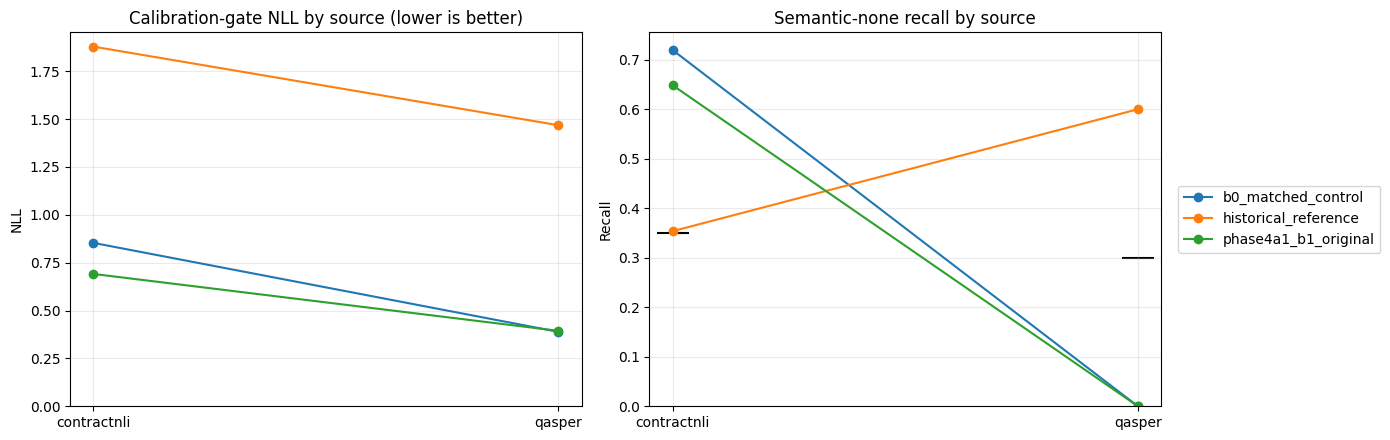

Saved comparison snapshot: /content/drive/MyDrive/Colab Notebooks/OpenDecision_Phase4A2_StateQuery_Model_Comparison_results/20260921T013558Z/comparison_snapshot_20260921T201409Z.json


In [12]:
import matplotlib.pyplot as plt

comparison_rows = []

def append_metric_rows(model_name, metrics_by_source, kind):
    for source, metrics in metrics_by_source.items():
        comparison_rows.append({
            "model": model_name,
            "kind": kind,
            "source": source,
            "n": metrics.get("n"),
            "accuracy": metrics.get("accuracy"),
            "balanced_accuracy": metrics.get("balanced_accuracy"),
            "macro_f1": metrics.get("macro_f1"),
            "nll": metrics.get("nll"),
            "brier": metrics.get("brier"),
            "ece15": metrics.get("ece15"),
            "semantic_none_recall": metrics.get("semantic_none_recall"),
        })

append_metric_rows(
    "historical_reference",
    BASE_NONFINAL["reference_by_source"],
    "baseline",
)
append_metric_rows(
    "phase4a1_b1_original",
    BASE_NONFINAL["custom_by_source"],
    "baseline",
)

variant_reports = []
for candidate in sorted(COMPARISON_ROOT.iterdir()):
    path = candidate / "NONFINAL_EVALUATION.json"
    contract = candidate / "EXPERIMENT_CONTRACT.json"
    if not path.is_file() or not contract.is_file():
        continue
    report = read_json(path)
    experiment = read_json(contract)
    if report.get("experiment_sha256") != experiment.get("experiment_sha256"):
        raise RuntimeError(f"Report/contract mismatch in {candidate.name}")
    if report.get("final_opened") is not False:
        raise RuntimeError(f"Final-opened report found in {candidate.name}")
    append_metric_rows(candidate.name, report["custom_by_source"], "phase4a2")
    variant_reports.append(report)

comparison = pd.DataFrame(comparison_rows)
display(comparison.sort_values(["source", "kind", "model"]).reset_index(drop=True))

macro_columns = [
    "accuracy", "balanced_accuracy", "macro_f1", "nll",
    "brier", "ece15", "semantic_none_recall",
]
macro = (
    comparison.groupby(["model", "kind"], as_index=False)[macro_columns]
    .mean(numeric_only=True)
    .sort_values(["kind", "nll", "model"])
)
display(macro)

if not comparison.empty:
    figure, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for model_name, group in comparison.groupby("model"):
        x = np.arange(len(group))
        axes[0].plot(
            group["source"], group["nll"], marker="o", label=model_name
        )
        axes[1].plot(
            group["source"], group["semantic_none_recall"],
            marker="o", label=model_name,
        )
    axes[0].set_title("Calibration-gate NLL by source (lower is better)")
    axes[0].set_ylabel("NLL")
    axes[1].set_title("Semantic-none recall by source")
    axes[1].set_ylabel("Recall")
    for source, floor in CFG["minimum_development_none_recall"].items():
        axes[1].scatter([source], [floor], marker="_", s=500, color="black")
    for axis in axes:
        axis.set_ylim(bottom=0)
        axis.grid(alpha=0.25)
    axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()

if variant_reports:
    snapshot = {
        "schema": "opendecision-phase4a2-comparison-snapshot/v1",
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
        "base_run_id": BASE_RUN_ID,
        "models": sorted(comparison["model"].unique()),
        "rows": comparison.to_dict("records"),
        "source_macro": macro.to_dict("records"),
        "final_opened": False,
    }
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    snapshot_path = COMPARISON_ROOT / f"comparison_snapshot_{stamp}.json"
    if not snapshot_path.exists():
        atomic_json(snapshot, snapshot_path)
    print("Saved comparison snapshot:", snapshot_path)
else:
    print("No Phase 4A.2 variant has completed yet; showing the two existing baselines.")


## 11. Final split barrier and handoff

Phase 4A.2 ends here. There is intentionally no `open_final` flag and no final-evaluation cell.

After B0, balanced B1, and B2 are compared:

1. choose one architecture using the predeclared non-final rule and source diagnostics;
2. freeze numerical promotion gates and the selected checkpoint in a new confirmatory contract;
3. run that fixed contract in a separate notebook;
4. open the final split once, with no reselection afterward.


In [13]:
def open_final_split(*args, **kwargs):
    raise PermissionError(
        "Final evaluation is intentionally unavailable in Phase 4A.2. "
        "Create a separate post-selection confirmatory notebook with frozen gates."
    )

if store is not None and "final" in store.accessed_splits:
    raise AssertionError("Final split was accessed.")
if REPORT is not None and REPORT.get("final_opened") is not False:
    raise AssertionError("Non-final report has an invalid final status.")
print("Final split remains closed. Phase 4A.2 comparison is the terminal action in this notebook.")


Final split remains closed. Phase 4A.2 comparison is the terminal action in this notebook.
